# Tugas Praktikum

## 2. Import Library

In [152]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Fungsi Tampil

In [153]:
def tampilkan_citra_2(img1, img2, title1='Citra Awal', title2='Citra Hasil', cmap1='gray', cmap2='gray'):
    plt.figure(figsize=(16, 8))
    
    plt.subplot(121)
    plt.imshow(img1, cmap=cmap1)
    plt.title(title1, fontsize=24)
    plt.xticks([]), plt.yticks([])
    
    plt.subplot(122)
    plt.imshow(img2, cmap=cmap2)
    plt.title(title2, fontsize=24)
    plt.xticks([]), plt.yticks([])
    
    plt.show()
    
def tampilkan_citra_3(img1, img2, img3, title1='Citra Awal', title2='Citra Biner', title3='Citra Hasil'):
    plt.figure(figsize=(16, 8))
    
    plt.subplot(131)
    plt.imshow(img1, cmap='gray')
    plt.title(title1, fontsize=24)
    plt.xticks([]), plt.yticks([])
    
    plt.subplot(132)
    plt.imshow(img2, cmap='gray')
    plt.title(title2, fontsize=24)
    plt.xticks([]), plt.yticks([])
    
    plt.subplot(133)
    plt.imshow(img3, cmap='gray')
    plt.title(title3, fontsize=24)
    plt.xticks([]), plt.yticks([])
    
    plt.show()


## 3.  **Dilasi** dengan Structuring Element Dilasi (SED) berbentuk cross 3 x 3 manual

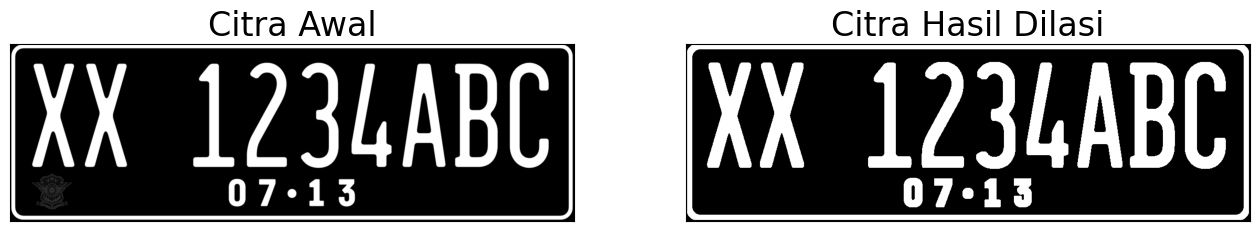

In [154]:
def dilasi_citra(F, w):
    # Size image
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)
    
    # Generate structure element dilasi (SED)
    SED = np.ones((w, w), dtype=np.uint8)
    constant1 = (w - 1) // 2
    
    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    
    return imgD

# Baca citra grayscale
img_d = cv2.imread('../images/plat_nomer.png', 0)

# Threshold citra
ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)

# Ukuran elemen struktur
w = 5

# Proses dilasi
imgD = dilasi_citra(thresh, w)

# Tampilkan hasil
tampilkan_citra_2(img_d, imgD, title1='Citra Awal', title2='Citra Hasil Dilasi')


## 4.  **Dilasi** dengan Structuring Element Dilasi (SED) berbentuk cross 3 x 3 OpenCV

[[1 1 1]
 [1 1 1]
 [1 1 1]]


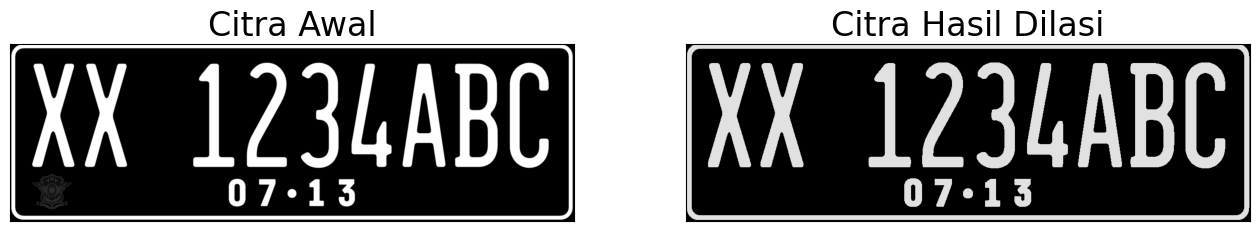

In [155]:
img = cv2.imread('../images/plat_nomer.png')

ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint16)
dilasi = cv2.dilate(thresh,kernel,iterations = 1)
print(kernel)

tampilkan_citra_2(img, dilasi, title1='Citra Awal', title2='Citra Hasil Dilasi')

## 5. **Erosi** dengan Structuring Element Erosi (SE) berbentuk square 5 x 5 tanpa openCV

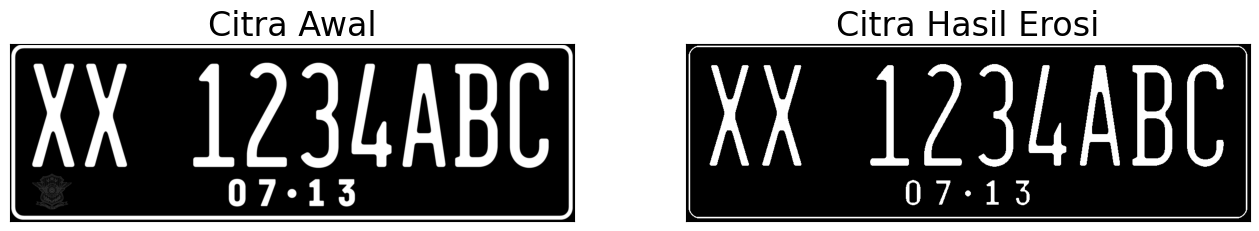

In [156]:
def erosi_citra(F,k):
    #size image
    m,n= F.shape
    #Generate structure element erosi (SE)
    SE= np.ones((k,k), dtype=np.uint8)
    constant= (k-1)//2
    imgE= np.zeros((m,n), dtype=np.uint8)
    #Proses Erosi
    for i in range(constant, m-constant):
        for j in range(constant,n-constant):
            temp= F[i-constant:i+constant+1, j- constant:j+constant+1]
            product= temp*SE
            imgE[i,j]= np.min(product)
    return imgE

img_e= cv2.imread('../images/plat_nomer.png',0) #
ret1, thresh1 = cv2.threshold(img_e, 175, 225,
cv2.THRESH_BINARY)
k=5
imgE = erosi_citra(thresh1,k)

tampilkan_citra_2(img_e, imgE, title1='Citra Awal', title2='Citra Hasil Erosi')

## 6. **Erosi** dengan Structuring Element Erosi (SE) berbentuk square 5 x 5 dengan openCV

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


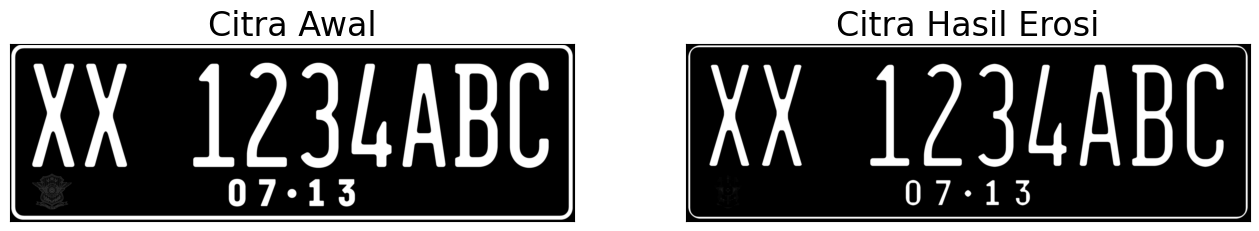

In [157]:
img = cv2.imread('../images/plat_nomer.png')

kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)
print(kernel)

tampilkan_citra_2(img, erosion, title1='Citra Awal', title2='Citra Hasil Erosi')

## 7. Operasi **Opening**

### Operasi Opening Menggunakan tanpa Library Morphology

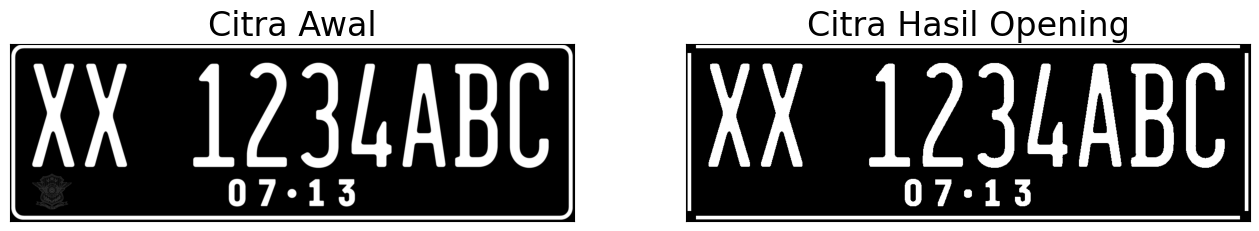

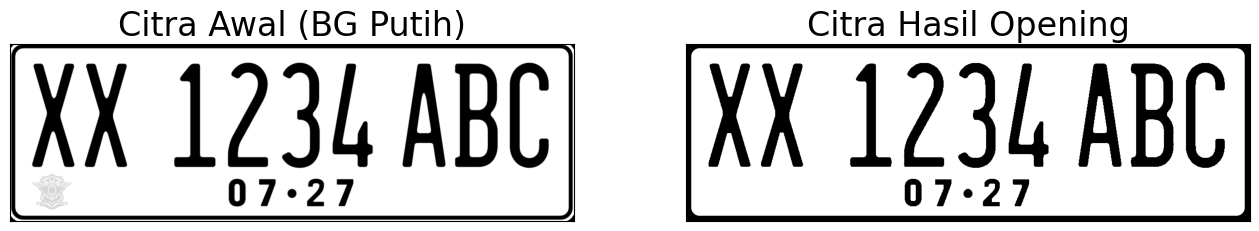

In [158]:
img_o= cv2.imread('../images/plat_nomer.png',0) 
img_o_2= cv2.imread('../images/plat_nomer_putih.png',0) 

reto, thresho = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY)
reto_2, thresho_2 = cv2.threshold(img_o_2, 127, 225, cv2.THRESH_BINARY)

k=7

imgO = dilasi_citra(erosi_citra(thresho,k),k)
imgO_2 = dilasi_citra(erosi_citra(thresho_2,k),k)

tampilkan_citra_2(img_o, imgO, title1='Citra Awal', title2='Citra Hasil Opening')
tampilkan_citra_2(img_o_2, imgO_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Opening')


### Operasi Opening Menggunakan Library Morphology

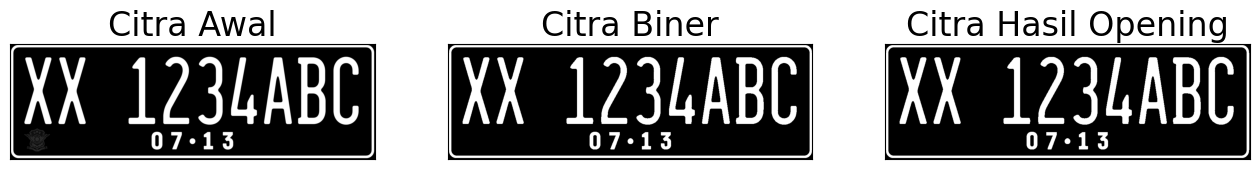

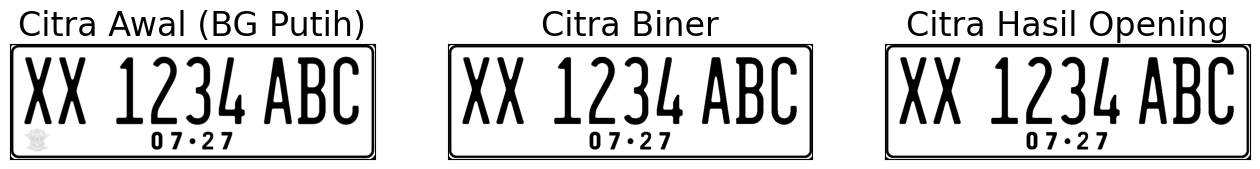

In [159]:
img = cv2.imread('../images/plat_nomer.png',0)
img_2 = cv2.imread('../images/plat_nomer_putih.png',0)

ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
ret_2, thresh_2 = cv2.threshold(img_2, 127, 225, cv2.THRESH_BINARY)

kernel = np.ones((3,3),np.uint8)

openn = cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)
openn_2 = cv2.morphologyEx(thresh_2,cv2.MORPH_OPEN, kernel)

tampilkan_citra_3(img, thresh, openn, title1='Citra Awal',title2='Citra Biner', title3='Citra Hasil Opening')
tampilkan_citra_3(img_2, thresh_2, openn_2, title1='Citra Awal (BG Putih)',title2='Citra Biner', title3='Citra Hasil Opening')


## 8. Operasi **Closing**

### Operasi closing tanpa library morphology

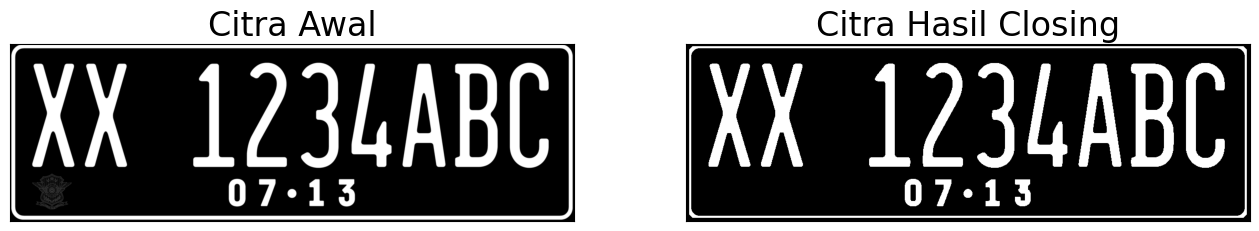

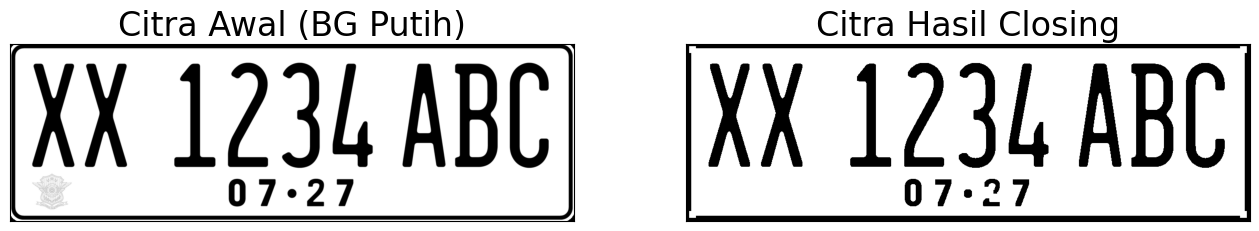

In [160]:
img_c= cv2.imread('../images/plat_nomer.png',0) #
img_c_2= cv2.imread('../images/plat_nomer_putih.png',0)
retc, threshc = cv2.threshold(img_c, 127, 225, cv2.THRESH_BINARY)
retc_2, threshc_2 = cv2.threshold(img_c_2, 127, 225, cv2.THRESH_BINARY)

k=7

imgC = erosi_citra(dilasi_citra(threshc,k),k)
imgC_2 = erosi_citra(dilasi_citra(threshc_2,k),k)

tampilkan_citra_2(img_c, imgC, title1='Citra Awal', title2='Citra Hasil Closing')
tampilkan_citra_2(img_c_2, imgC_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Closing')

### Operasi closing dengan library morphology

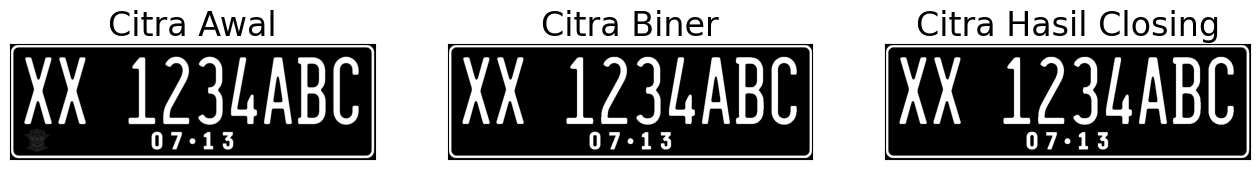

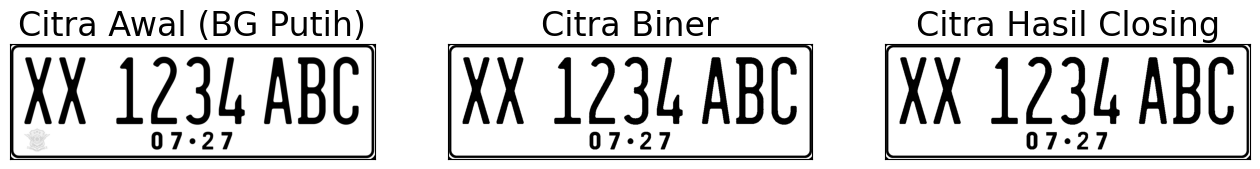

In [161]:
img = cv2.imread('../images/plat_nomer.png',0)
img_2 = cv2.imread('../images/plat_nomer_putih.png',0)

ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
ret_2, thresh_2 = cv2.threshold(img_2, 127, 225, cv2.THRESH_BINARY)

kernel = np.ones((3,3),np.uint8)

closs = cv2.morphologyEx(thresh,cv2.MORPH_CLOSE, kernel)
closs_2 = cv2.morphologyEx(thresh_2,cv2.MORPH_CLOSE, kernel)

tampilkan_citra_3(img, thresh, closs, title1='Citra Awal',title2='Citra Biner', title3='Citra Hasil Closing')
tampilkan_citra_3(img_2, thresh_2, closs_2, title1='Citra Awal (BG Putih)',title2='Citra Biner', title3='Citra Hasil Closing')

## 9. Operasi dilasi dengan Structuring Element berbentuk Cross 3 x 3 dan 5 x 5

SED = Cross 3


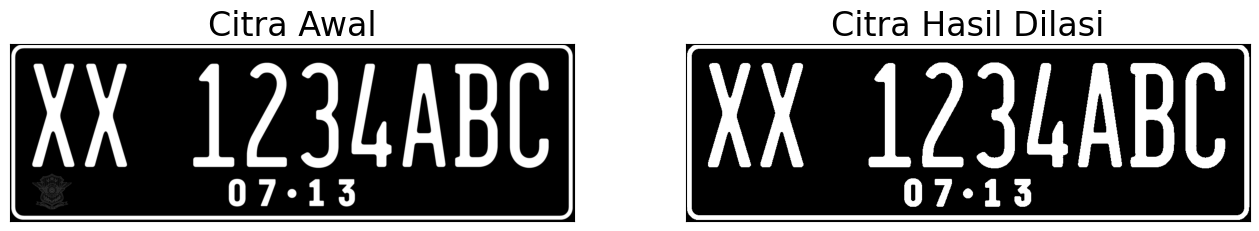

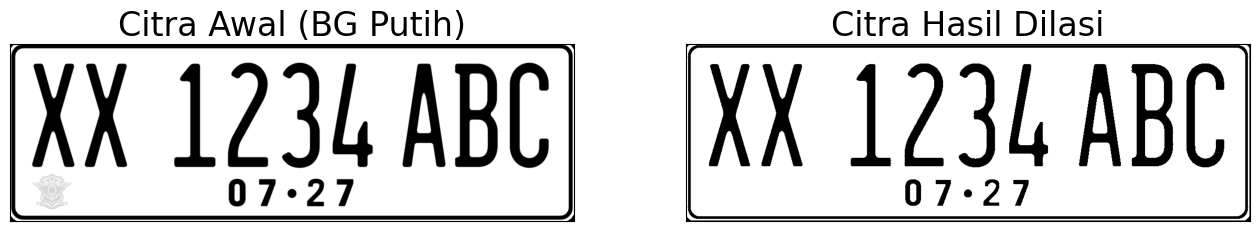

SED = Cross 5


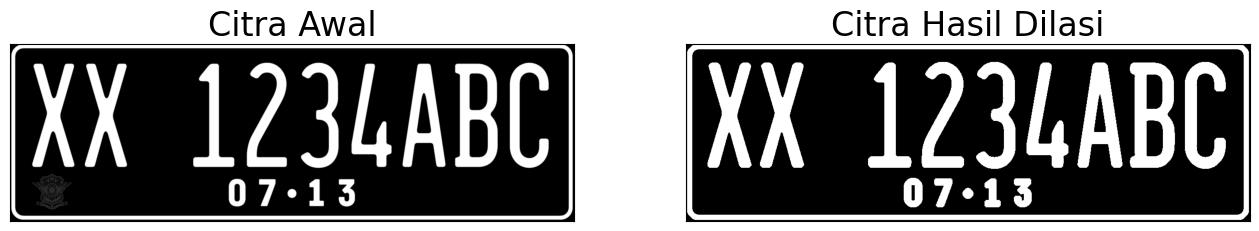

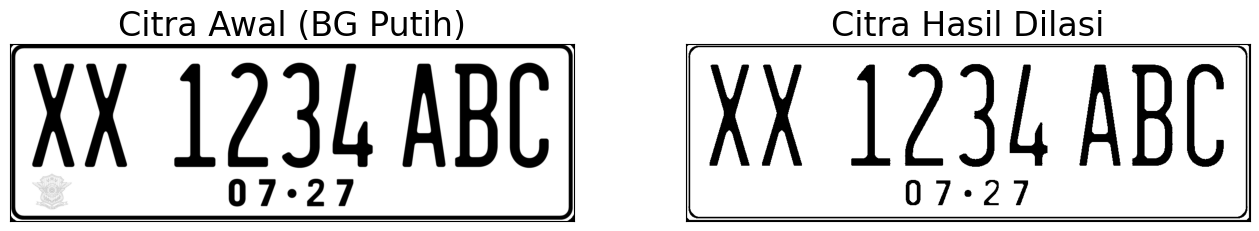

In [162]:
#Dilasi Cross SED
def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    # SED= np.ones((w,w), dtype=np.uint8)
    SED = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype = np.uint8)
    constant1= (w-1)//2
    
    #Proses Dilasi
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp*SED
            imgD[i,j]= np.max(product)
    return imgD

print('SED = Cross 3')

img_d= cv2.imread('../images/plat_nomer.png',0)
img_d_2 = cv2.imread('../images/plat_nomer_putih.png',0)

ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
ret_2, thresh_2 = cv2.threshold(img_d_2, 127, 225, cv2.THRESH_BINARY)

w=3

imgD = dilasi_citra(thresh,w)
imgD_2 = dilasi_citra(thresh_2,w)

tampilkan_citra_2(img_d, imgD, title1='Citra Awal', title2='Citra Hasil Dilasi')
tampilkan_citra_2(img_d_2, imgD_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Dilasi')




def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    # SED= np.ones((w,w), dtype=np.uint8)
    SED = np.array([[0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0],
                    [1, 1, 1, 1, 1],
                    [0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0]], dtype = np.uint8)
    constant1= (w-1)//2
    #Proses Dilasi
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp*SED
            imgD[i,j]= np.max(product)
    return imgD

print('SED = Cross 5')

img_d= cv2.imread('../images/plat_nomer.png',0)
img_d_2 = cv2.imread('../images/plat_nomer_putih.png',0)

ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
ret_2, thresh_2 = cv2.threshold(img_d_2, 127, 225, cv2.THRESH_BINARY)

w=5

imgD = dilasi_citra(thresh,w)
imgD_2 = dilasi_citra(thresh_2,w)

tampilkan_citra_2(img_d, imgD, title1='Citra Awal', title2='Citra Hasil Dilasi')
tampilkan_citra_2(img_d_2, imgD_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Dilasi')

## 10. Operasi dilasi dengan Structuring Element berbentuk Circular 3 x 3 dan 5 x 5

SED = Circular 3


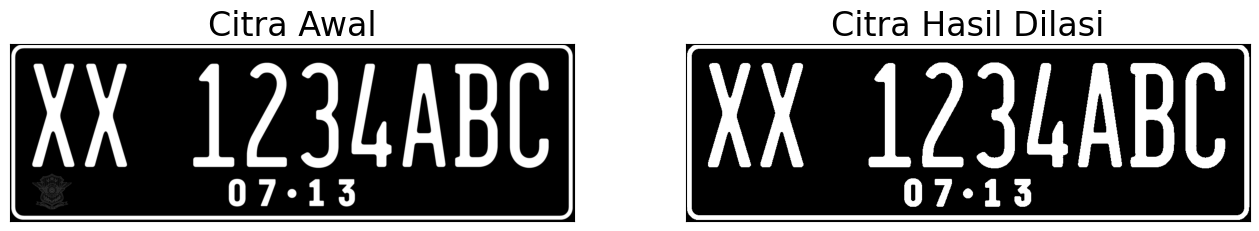

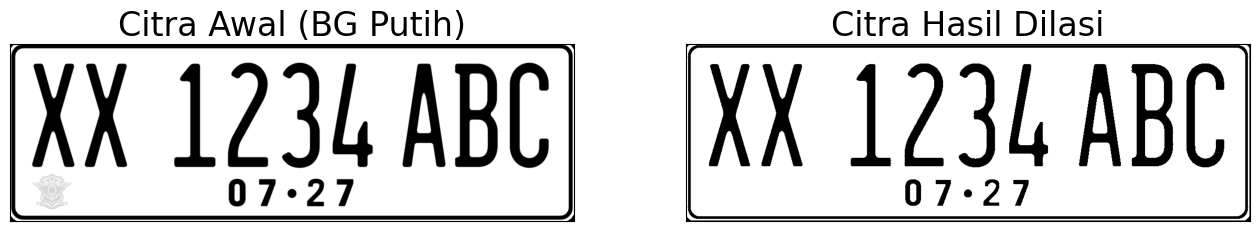

SED = Circular 5


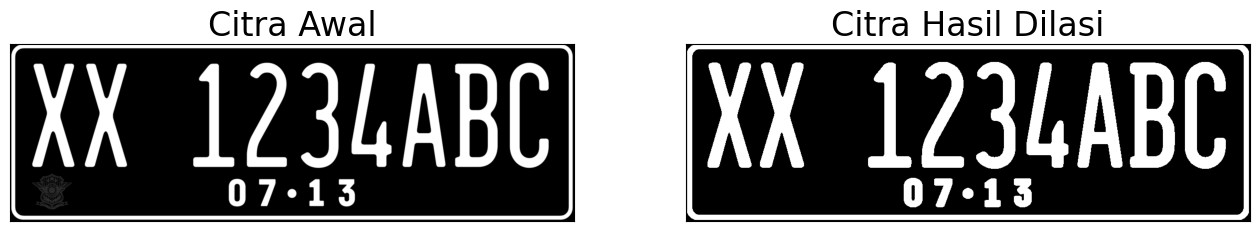

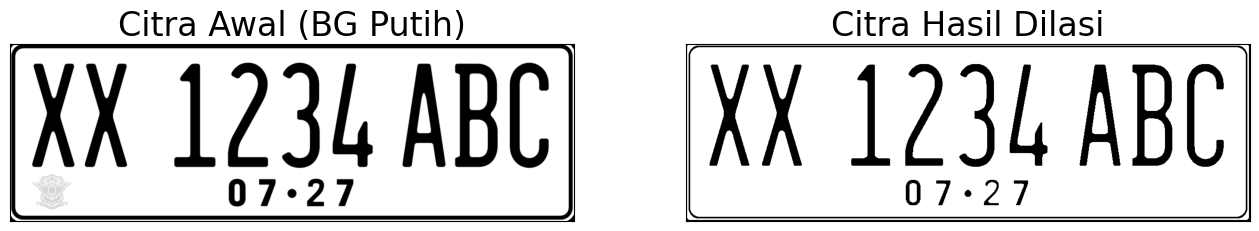

In [163]:
#Dilasi Circular SED
def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    SED= cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(w,w))
    constant1= (w-1)//2
    #Proses Dilasi
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp*SED
            imgD[i,j]= np.max(product)
    return imgD

print('SED = Circular 3')

img_d= cv2.imread('../images/plat_nomer.png',0)
img_d_2 = cv2.imread('../images/plat_nomer_putih.png',0)

ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
ret_2, thresh_2 = cv2.threshold(img_d_2, 127, 225, cv2.THRESH_BINARY)

w=3

imgD = dilasi_citra(thresh,w)
imgD_2 = dilasi_citra(thresh_2,w)

tampilkan_citra_2(img_d, imgD, title1='Citra Awal', title2='Citra Hasil Dilasi')
tampilkan_citra_2(img_d_2, imgD_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Dilasi')

print('SED = Circular 5')

w=5

imgD = dilasi_citra(thresh,w)
imgD_2 = dilasi_citra(thresh_2,w)

tampilkan_citra_2(img_d, imgD, title1='Citra Awal', title2='Citra Hasil Dilasi')
tampilkan_citra_2(img_d_2, imgD_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Dilasi')


## 11. Operasi erosi dengan Structuring Element berbentuk Rectangle 3 x 5 dan 5 x 7

SE = Rectangle 3x5


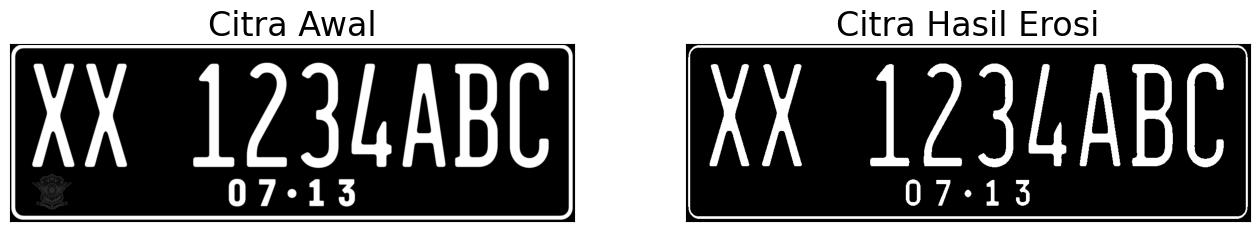

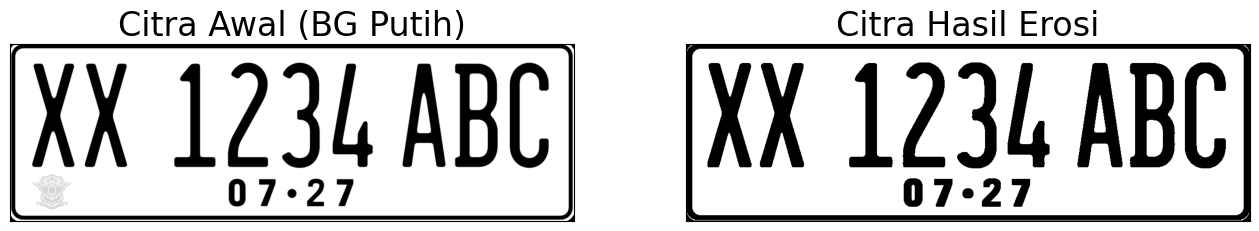

SE = Rectangle 5x7


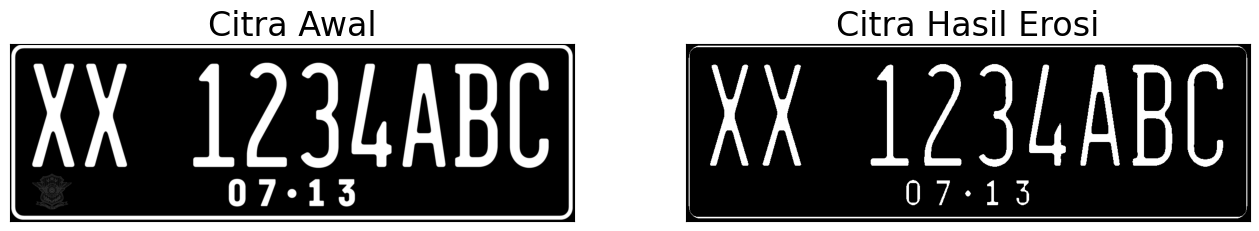

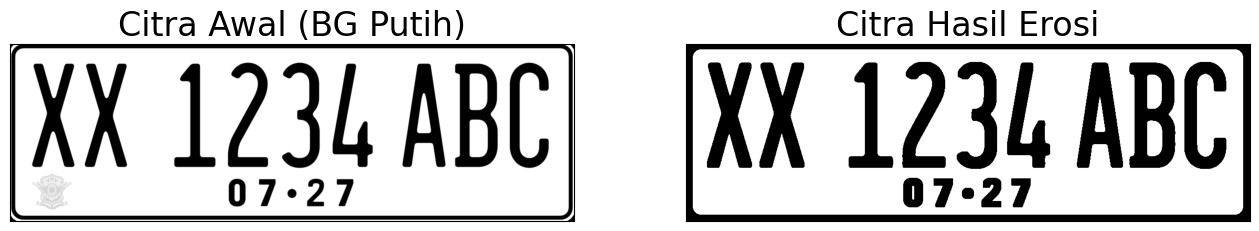

In [164]:
def erosi_citra(F,p,l):
#size image
    m,n= F.shape
    #Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT,(p,l))
    constant1= (l-1)//2
    constant2= (p-1)//2
    # print(SE)
    imgE= np.zeros((m,n), dtype=np.uint8)
    #Proses Erosi
    for i in range(constant1, m-constant1):
        for j in range(constant2,n-constant2):
            temp= F[i-constant1:i+constant1+1, j-constant2:j+constant2+1]
            product= temp*SE
            imgE[i,j]= np.min(product)
    return imgE

print('SE = Rectangle 3x5')
img_e= cv2.imread('../images/plat_nomer.png',0) 
img_e_2 = cv2.imread('../images/plat_nomer_putih.png',0)

ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
ret_2, thresh_2 = cv2.threshold(img_e_2, 127, 225, cv2.THRESH_BINARY)   
p=5; l=3
imgE = erosi_citra(thresh1,p,l)
imgE_2 = erosi_citra(thresh_2,p,l)

tampilkan_citra_2(img_e, imgE, title1='Citra Awal', title2='Citra Hasil Erosi')
tampilkan_citra_2(img_e_2, imgE_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Erosi')

print('SE = Rectangle 5x7')

p=7; l=5
imgE = erosi_citra(thresh1,p,l)
imgE_2 = erosi_citra(thresh_2,p,l)

tampilkan_citra_2(img_e, imgE, title1='Citra Awal', title2='Citra Hasil Erosi')
tampilkan_citra_2(img_e_2, imgE_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Erosi')


## 12. Operasi erosi dengan Structuring Element berbentuk Line Vertikal 3 dan 5

SE = Line Vertikal 3


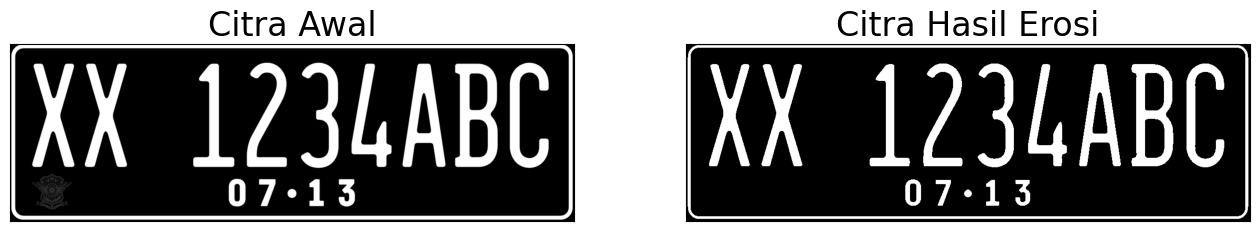

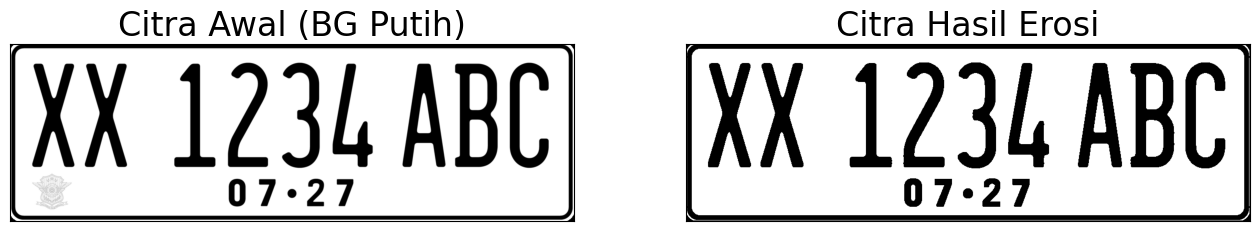

SE = Line Vertikal 5


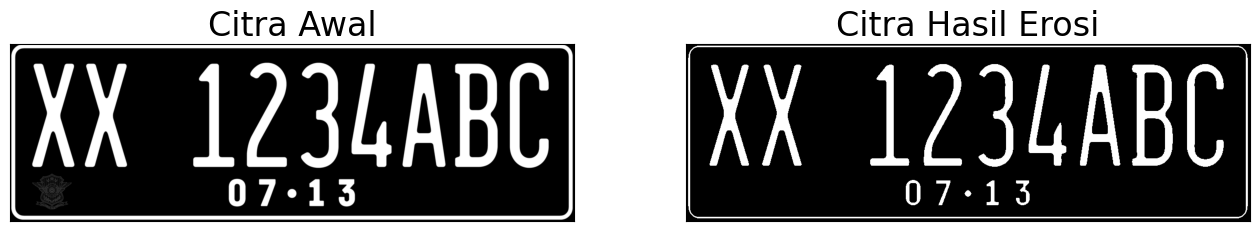

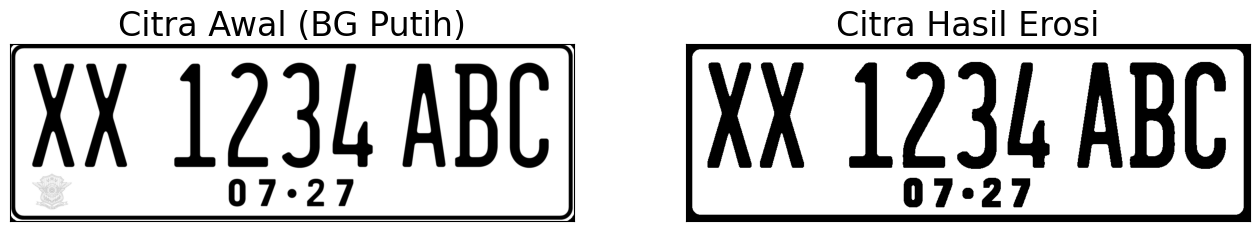

In [165]:
def erosi_citra(F,k):
    m,n= F.shape
    #Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(1,k)) #SE line vertikal
    constant= (k-1)//2
    imgE= np.zeros((m,n), dtype=np.uint8)
    #Proses Erosi
    for i in range(constant, m-constant):
        for j in range(constant,n-constant):
            temp= F[i-constant:i+constant+1, j-
            constant:j+constant+1]
            product= temp*SE
            imgE[i,j]= np.min(product)
    return imgE

print('SE = Line Vertikal 3')
img_e= cv2.imread('../images/plat_nomer.png',0)
img_2 = cv2.imread('../images/plat_nomer_putih.png',0)

ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
ret_2, thresh_2 = cv2.threshold(img_2, 127, 225, cv2.THRESH_BINARY)
k=3
imgE = erosi_citra(thresh1,k)
imgE_2 = erosi_citra(thresh_2,k)

tampilkan_citra_2(img_e, imgE, title1='Citra Awal', title2='Citra Hasil Erosi')
tampilkan_citra_2(img_2, imgE_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Erosi')

print('SE = Line Vertikal 5')

k=5
imgE = erosi_citra(thresh1,k)
imgE_2 = erosi_citra(thresh_2,k)

tampilkan_citra_2(img_e, imgE, title1='Citra Awal', title2='Citra Hasil Erosi')
tampilkan_citra_2(img_2, imgE_2, title1='Citra Awal (BG Putih)', title2='Citra Hasil Erosi')

## 13. TopHat

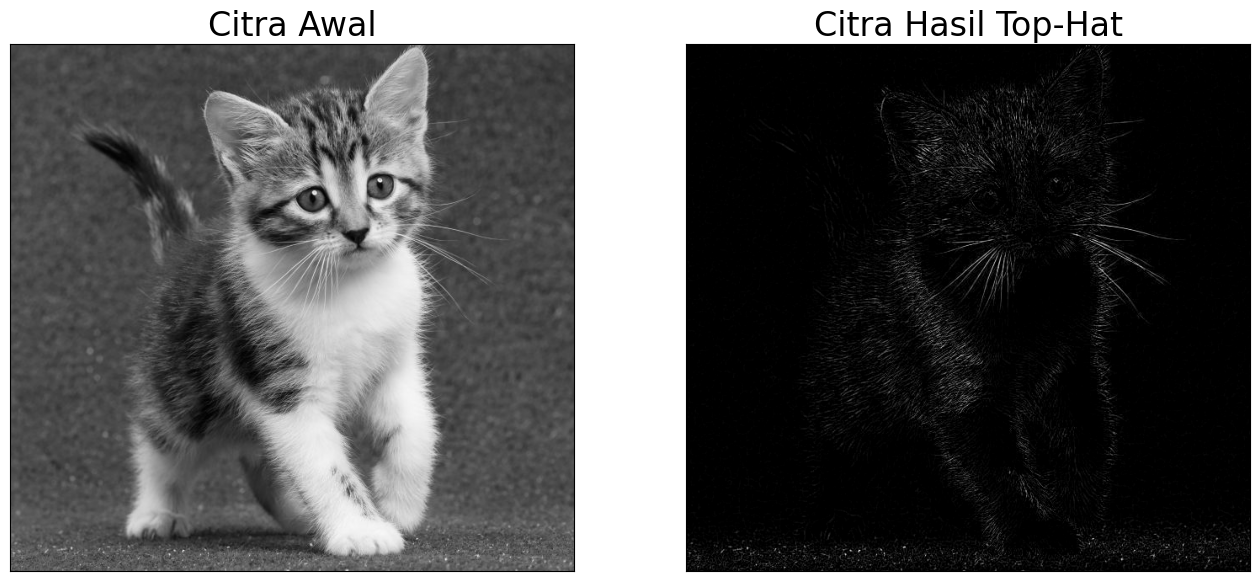

In [166]:
filterSize =(3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

img = cv2.imread('../images/kitten01.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Top-Hat operation
tophat_img = cv2.morphologyEx(img,cv2.MORPH_TOPHAT,kernel)


tampilkan_citra_2(img, tophat_img, title1='Citra Awal', title2='Citra Hasil Top-Hat')

## 14. BLACKHAT

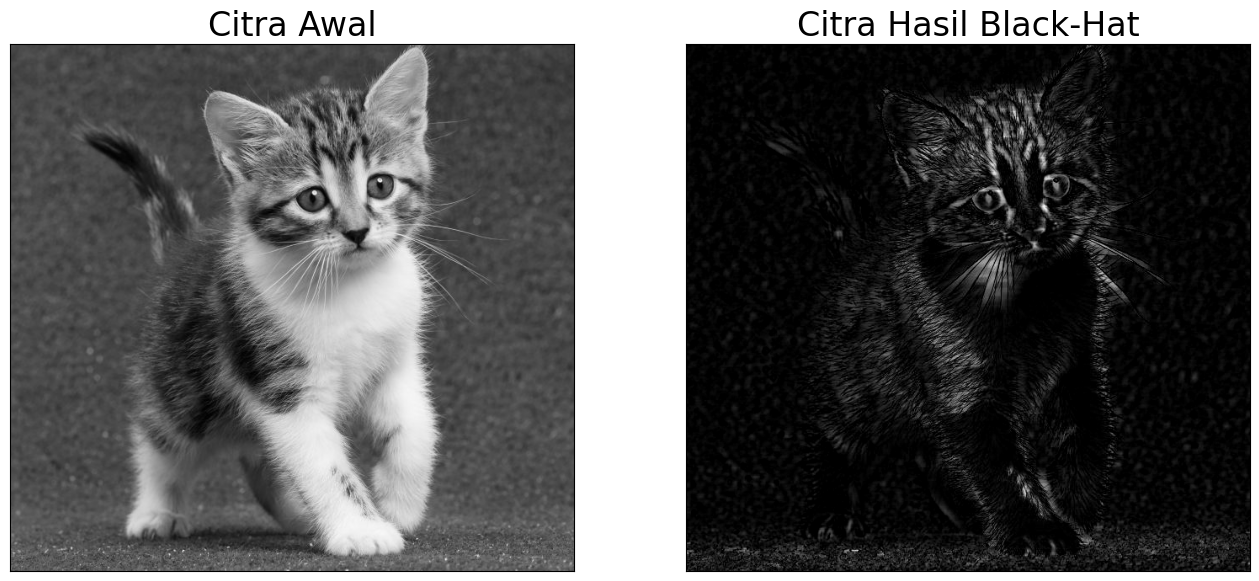

In [167]:
filterSize =(3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

img = cv2.imread('../images/kitten01.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, Kernel)

tampilkan_citra_2(img, blackhat, title1='Citra Awal', title2='Citra Hasil Black-Hat')

## 15. Skeleton

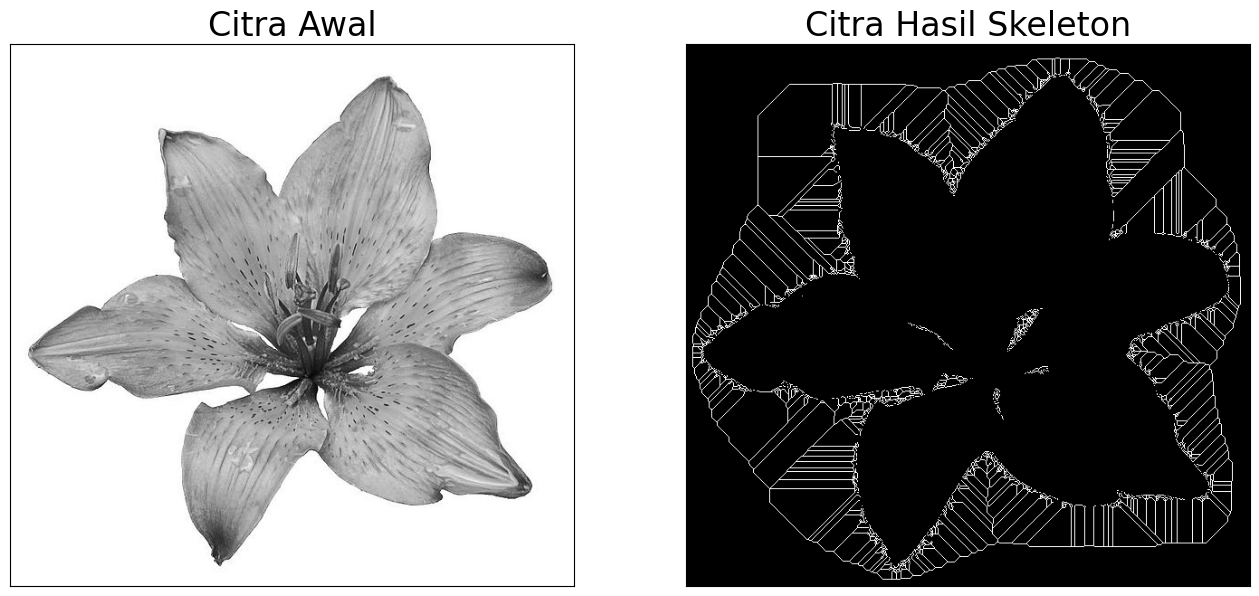

In [168]:
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# read image
img = cv.imread('../images/lily.jpg',0)
binary = img > filters.threshold_triangle(img)

# true false to one
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# skeletonize image
skeleton = skeletonize(binary_cp)


# print images
tampilkan_citra_2(img, skeleton, title1='Citra Awal', title2='Citra Hasil Skeleton')

## 16. Skeleton Inverse

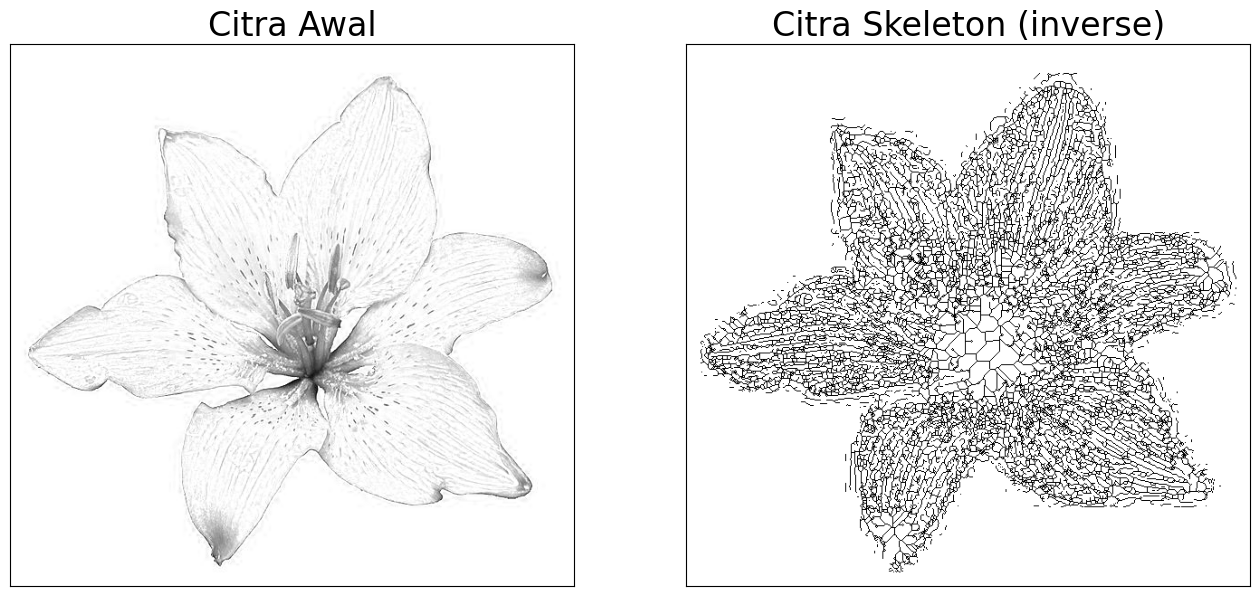

In [170]:
from skimage import io
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# read image
img = io.imread('../images/lily.jpg')[..., 0]

# Note: we want the black bits to be True, so use <
binary = img < filters.threshold_triangle(img)

# skeletonize image
skeleton = skeletonize(binary)

# print images
tampilkan_citra_2(img, skeleton, title1='Citra Awal', title2='Citra Skeleton (inverse)', cmap2='gray_r')

## 17. Thickening

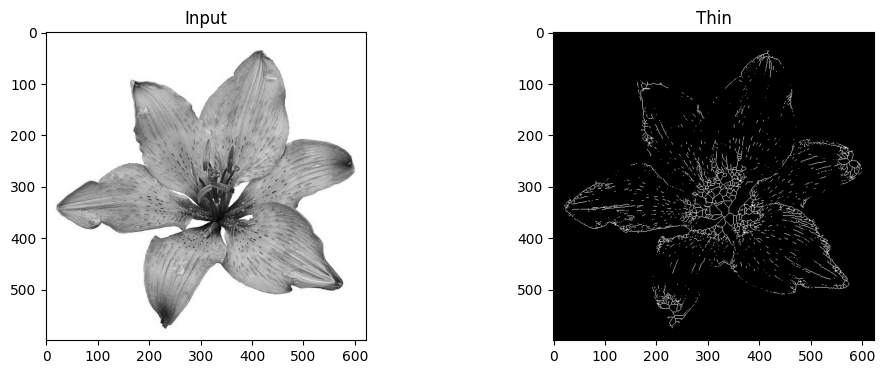

In [174]:
from skimage import img_as_float
from skimage import io, color, morphology
import matplotlib.pyplot as plt

image = img_as_float(color.rgb2gray(io.imread('../images/lily.jpg')))

image_binary = image < 0.5
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)


f, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4))

ax0.imshow(image, cmap='gray')
ax0.set_title('Input')
ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
plt.savefig('/tmp/char_out.png')
plt.show()